In [31]:
import torch
import time
import copy
import os
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from rl.dreamer.rssm import ConvDecoder, ConvEncoder


if os.path.basename(os.getcwd()) == 'exercises':
    os.chdir('../')
    
from ctm.ctm_rl import ContinuousThoughtMachineRL
from ctm.ctm import ContinuousThoughtMachine


In [32]:
device_config = -1

# Configure device string (support MPS on macOS)
if device_config != -1:
    device = f'cuda:{device_config}'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
print(f'Running model CTM on {device}')
torch.set_default_device(device)

Running model CTM on cpu


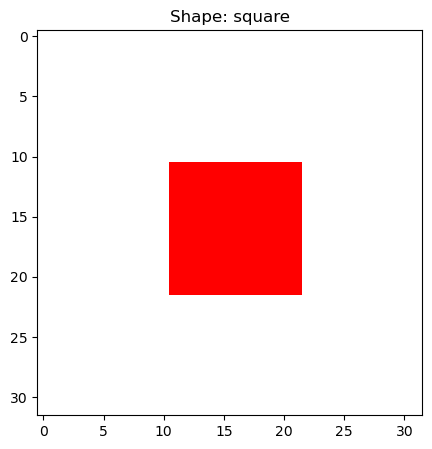

In [33]:
from environments.shape_environment.shape_env import ShapeEnv

env = ShapeEnv(time_scaling=0, img_size=32, sizes=[5,10], colors=['red', 'green', 'blue'], shapes=['circle', 'triangle', 'square'], random_position=False, device=device, random_initial=True)

img = env.render()

# 3. Display using Matplotlib
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Shape: {env.shapes_list[env.shape_size_idx // len(env.sizes_list)]}")
plt.show()

In [52]:
def compare_result(actual_img, predicted_img):
    # actual_img: [1, 3, 32, 32] tensor
    # predicted_img: [1, 3, 32, 32] tensor
    
    actual = actual_img.squeeze(0).cpu().permute(1, 2, 0).numpy()
    pred = predicted_img.squeeze(0).detach().cpu().permute(1, 2, 0).numpy()
    
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Target (Ground Truth)")
    plt.imshow(actual)
    
    plt.subplot(1, 2, 2)
    plt.title("CTM Imagination")
    plt.imshow(pred)
    plt.show()

In [ ]:
# Not relevant I think but don't want to delete it :D

"""
Basic init for the CTM. More enhanced description is in ctm.py

Mandatory Args:
    iterations = ticks (75 like maze demo)
    d_model = core dimensionality of CTMS's latent space
    n_sync_out = neurons used for output synchronisation 
    n_sync_action = neurons used for action/attention synchronisation 
    synapse_depth = Depth of the synapse model (U-Net if > 1, else MLP)
    memory_length = History length for Neuron-Level Model
    deep_nlms = Deep NLM is better but slower
    memory_hidden_dims = Hidden dimension size for deep NLMs.
    do_layernorm_nlm = Untested in the paper
    backbone_type = Type of feature extraction backbone (e.g., 'resnet18-2', 'none') Maybe insert encoder here
    positional_embedding_type = positional embedding ???
---------
Optional args:
    prediction_reshaper
    dropout
    neuron_select_type
    n_random_pairing_self
"""
LAT, CAT, DET = 16, 16, 256 # Dreamer latent space dimensions, deterministic hidden state as well as stochastic (latent dimensions, number of categories)
d_input = 256 
batch_size = 1
seq_len = 1

img_enc = ConvEncoder(output_dim=256)
img_dec = ConvDecoder(input_dim=256)

print(f"Initial image shape: {img.shape}")
img_tensor = torch.from_numpy(img.T).float()
img_tensor = img_tensor.unsqueeze(0)
print(f"Tensor Shape for Encoder: {img_tensor.shape}")

encoded_img = img_enc.forward(img_tensor)
#TODO: add seq_len (Is it the first = 1 or the 10th image = 10)

print(f"Encoded Image Shape: {encoded_img.shape}")
ctm = ContinuousThoughtMachine(iterations=75, 
                               d_model=2048, 
                               d_input=d_input, 
                               heads=8, 
                               n_synch_out=64, 
                               n_synch_action=32,
                               synapse_depth=8, 
                               memory_length=25, 
                               deep_nlms=False,
                               memory_hidden_dims=32, 
                               do_layernorm_nlm=False,
                               backbone_type='none',
                               positional_embedding_type='none',
                               out_dims=256
                               )

try:
    # Determine pseudo input shape based on dataset
    pseudo_inputs = torch.zeros((batch_size, seq_len, d_input), device=device).float()
    print(pseudo_inputs.shape)
    ctm(pseudo_inputs)
except Exception as e:
        print(f"Warning: Pseudo forward pass failed: {e}")

latent = encoded_img.unsqueeze(1)
predictions_raw, certainties, synchronisation = ctm(latent)
final_thought = predictions_raw[:, :, -1]  # Result: [1, 256]
decoded_img = img_dec(final_thought)

#TODO: build a training loop
#TODO: calculate the loss like in the dreamer model example


Initial image shape: (32, 32, 3)
Tensor Shape for Encoder: torch.Size([1, 3, 32, 32])
Encoded Image Shape: torch.Size([1, 256])
Using neuron select type: random-pairing
Synch representation size action: 32
Synch representation size out: 64
torch.Size([1, 1, 256])


torch.Size([1, 256, 75])
torch.Size([1, 2, 75])
torch.Size([1, 64])


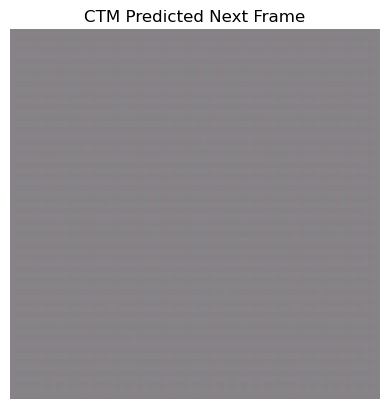

In [53]:
print(predictions_raw.shape)
print(certainties.shape)
print(synchronisation.shape)

img_np = decoded_img.squeeze(0).cpu().detach().permute(1, 2, 0).numpy()

# 4. Plot
plt.imshow(img_np)
plt.axis('off')
plt.title("CTM Predicted Next Frame")
plt.show()

In [ ]:
"""
Basic init for the CTM. More enhanced description is in ctm.py

Mandatory Args:
    iterations = ticks (75 like maze demo)
    d_model = core dimensionality of CTMS's latent space
    n_sync_out = neurons used for output synchronisation 
    synapse_depth = Depth of the synapse model (U-Net if > 1, else MLP)
    memory_length = History length for Neuron-Level Model
    deep_nlms = Deep NLM is better but slower
    memory_hidden_dims = Hidden dimension size for deep NLMs.
    do_layernorm_nlm = Untested in the paper
    backbone_type = Type of feature extraction backbone (e.g., 'resnet18-2', 'none') Maybe insert encoder here
    positional_embedding_type = positional embedding ???
---------
Optional args:
    prediction_reshaper
    dropout
    neuron_select_type
    n_random_pairing_self
"""
ctm = ContinuousThoughtMachineRL(iterations=75, 
                               d_model=2048, 
                               d_input=256, 
                               n_synch_out=64, 
                               synapse_depth=8, 
                               memory_length=25, 
                               deep_nlms=False,
                               memory_hidden_dims=32, 
                               do_layernorm_nlm=False,
                               backbone_type='simple-shape-backbone',
                               )

actor_input_dim = critic_input_dim = ctm.synch_representation_size_out

actor = nn.Sequential(
            layer_init(nn.Linear(actor_input_dim, 64), std=1),
            nn.ReLU(),
            layer_init(nn.Linear(64, 64), std=1),
            nn.ReLU(),
            layer_init(nn.Linear(64, size_action_space), std=1)
        )

critic = nn.Sequential(
            layer_init(nn.Linear(critic_input_dim, 64), std=1),
            nn.ReLU(),
            layer_init(nn.Linear(64, 64), std=1),
            nn.ReLU(),
            layer_init(nn.Linear(64, 1), std=1)
        )
#TODO: How can we calculate the loss/reward of the picture 
#TODO: build a training loop
#TODO: calculate the loss like in the dreamer model example


Using neuron select type: first-last
Synch representation size action: 0
Synch representation size out: 2080
